In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sales.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'sales.csv'

In [3]:
import os
os.listdir()

['.ipynb_checkpoints', 'predictive_analysis.ipynb', 'train.csv']

In [4]:
df = pd.read_csv("train.csv")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [8]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [11]:
df['Order Date'].head()

0    08/11/2017
1    08/11/2017
2    12/06/2017
3    11/10/2016
4    11/10/2016
Name: Order Date, dtype: str

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)

In [14]:
id="z5s8cd"
df = df.sort_values('Order Date')

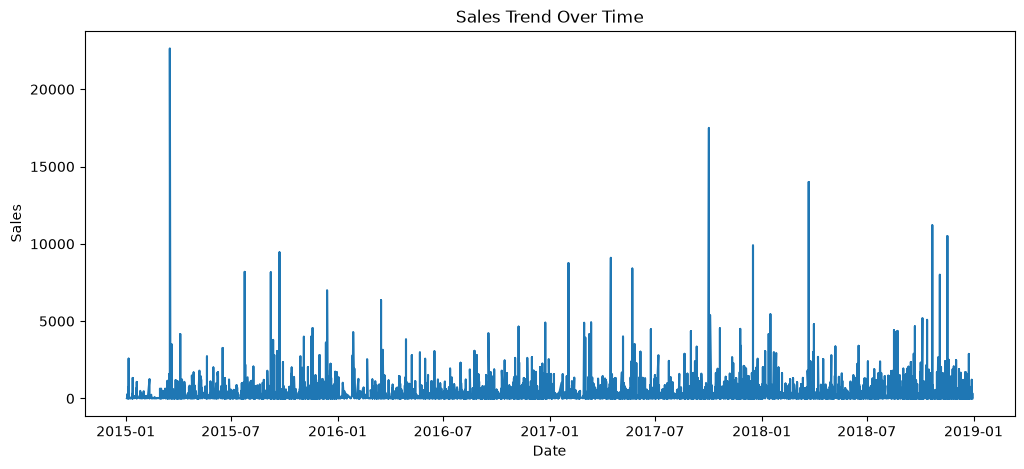

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['Order Date'], df['Sales'])
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [16]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.head()

Order Date
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Freq: M, Name: Sales, dtype: float64

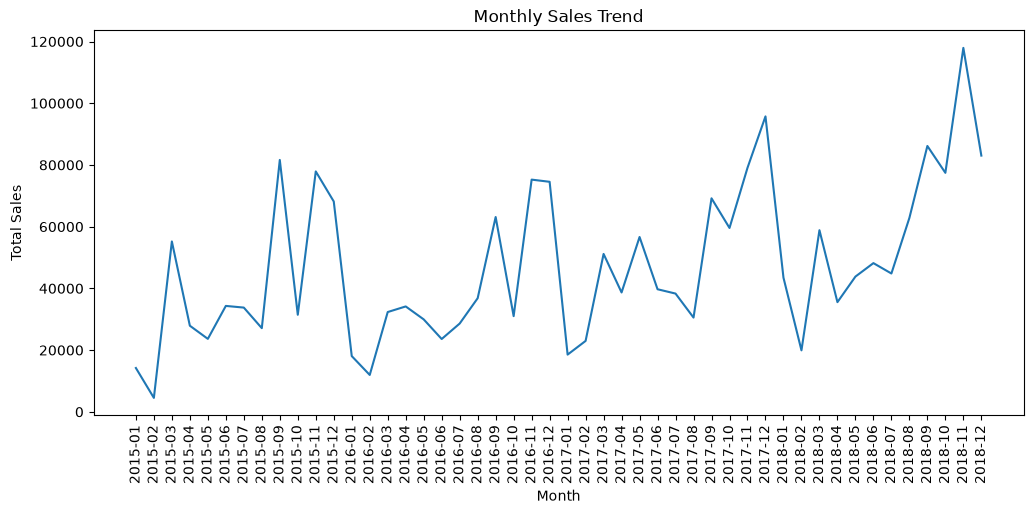

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)
plt.show()

In [18]:
monthly_sales = monthly_sales.reset_index()

monthly_sales.columns = ['Month', 'Sales']

monthly_sales.head()

,Month,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


In [19]:
id="9p8n7z"
monthly_sales['Month_Number'] = range(1, len(monthly_sales)+1)

monthly_sales.head()

,Month,Sales,Month_Number
0,2015-01,14205.707,1
1,2015-02,4519.892,2
2,2015-03,55205.797,3
3,2015-04,27906.855,4
4,2015-05,23644.303,5


In [20]:
X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[888.31]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Month_Number']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.535e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [22]:
future_months = [[len(monthly_sales)+1],
                 [len(monthly_sales)+2],
                 [len(monthly_sales)+3]]

predictions = model.predict(future_months)

predictions

C:\Users\Sheetal Rawat\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([68878.99833333, 69767.31052491, 70655.6227165 ])

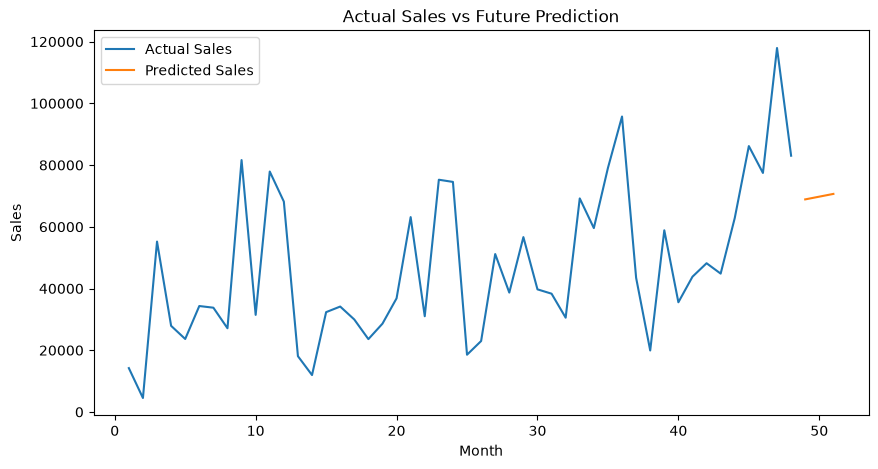

In [23]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['Month_Number'], monthly_sales['Sales'], label="Actual Sales")

future_x = [len(monthly_sales)+1, len(monthly_sales)+2, len(monthly_sales)+3]

plt.plot(future_x, predictions, label="Predicted Sales")

plt.title("Actual Sales vs Future Prediction")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.legend()
plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

predicted_sales = model.predict(X)

mae = mean_absolute_error(y, predicted_sales)
rmse = np.sqrt(mean_squared_error(y, predicted_sales))
r2 = r2_score(y, predicted_sales)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 17400.980583528202
RMSE: 21435.834811227283
R2 Score: 0.24788377074044887
